# **Getting Started With the Notebook**

This notebook is organized into **simple, collapsible sections** so you can easily navigate and run only what you need.

#### **Step 1**: Initial Setup
Start by running the **“Initial Setup and Authentication”** section. This prepares everything needed for the notebook to work properly.

#### ⚠️ First-Time Users Only
If this is your **first time opening this workspace**:
1. Run the initial setup  
2. **Restart (relaunch) the workspace**  
3. Run the **“Initial Setup and Authentication”** section again  
> 💡 You only need to do this once per new workspace.

####  **Step 2**: Provide Your Data
Provide the `hubmap_id` for the dataset you want to work with. This tells the notebook which data to use.

#### **Step 3**: Run the Analysis
- Go to any section you want to explore and run the cells in that section 

#### Running Cells
- **Shift + Enter** → Run cell and move to the next one 
- **Ctrl + Enter** → Run cell and stay on the same one

#### Understanding the Sections
- Each section is **independent** → you can run them in any order *(after setup)*  
- Within a section → run cells **from top to bottom**  
- Each section is **self-contained** and labeled to guide you 
> 💡 **Tip:** If you're unsure where to start, just follow the steps in order — everything is designed to guide you along the way.

## Table of Contents

> 💡 **Tip:** Use the **Table of Contents** icon (☰) in the left sidebar to quickly jump between sections.

#### 1. **Getting Started** 
Begin here to set everything up:
1. Initial Setup and Authentication

#### 2. **Data Management**
Use these steps to find and prepare your data:

2. Fetch Data from HubMAP  
3. Download to Workspace  
4. Push to Fusion Backend  

#### 3. **Run Analysis Jobs**
Run different analysis workflows on your data:

5. Available workflows include:
   - Multi-Compartment Segmentation  
   - Frozen Glomerulus Segmentation  
   - Expanded Granular Feature Extraction 
   - Spot Data Generation  
     - Label Transfer  
     - Spot Annotation  
   - Spatial Aggregation

#### 4. **Visualization**
Explore and view your results:

6. Visualize HuBMAP Data  
7. Visualize 10x Visium Spatial-Omics Data from Fusion Backend  

#### 5. **Miscellaneous Tools**
Additional helpful utilities:

8. Convert Multi-Frame Image to Single-Frame  

# **FUSION++ Features**

In [ ]:
import os
os.listdir("Images")

![FUSION++_Features](Images/FUSION++_Features.png)

# **Initial Setup and Authentication**

In [ ]:
from IPython.display import clear_output

print("⏳ Installing dependencies... this may take a moment.")

!pip install large_image[all] --find-links https://girder.github.io/large_image_wheels
!jupyter server extension enable jupyter_server_proxy

clear_output(wait=True)
print("✅ Installation and setup successful!")

In [ ]:
import getpass

# Authenticate
user_name = input("Enter your username: ")
auth_pass = getpass.getpass("Enter your password: ")

import girder_client
gc = girder_client.GirderClient(apiUrl='https://fusionpub.rc.ufl.edu/api/v1')
try:
    user_info = gc.authenticate(user_name, auth_pass)
    print(f"Login Successful: {user_info['firstName']} {user_info['lastName']} ({user_info['email']})")
except Exception as e:
    print(f"Login Failed: {e}")

# **Select Your HuBMAP Dataset**


To find a HuBMAP dataset ID:

1. **Navigate to the HuBMAP Data Portal:** Go to [portal.hubmapconsortium.org](https://portal.hubmapconsortium.org/)
2. **Browse Datasets:** Click on "Datasets" in the navigation menu
3. **Choose a Dataset:** Browse or search for a dataset that interests you
4. **Copy the HuBMAP ID:** Each dataset has a unique identifier (e.g., `HBM123.ABCD.456`)

**Then add your selected ID to the cell below:**

In [4]:
hubmap_id = "HBM533.TLNG.967"  # Replace this with the ID you copied from the portal

# **Data Management Features**

This section contains four key features for working with your selected dataset:

- **1. Display Dataset Files and Paths** : Shows the files and file paths available in the selected dataset

- **2. Download the Dataset to the Workspace** : Downloads one or more HuBMAP datasets to a local workspace directory

- **3. Upload to Fusion Platform** : Uploads the selected HuBMAP dataset files to the Fusion platform

- **4. download data from Fusion Platform**: 
    * Download file or item from Fusion platform to the workspace.
    * Download predefined model_files from Fusion platform
    * Download predefined reference_files from Fusion platform

#### **1. Display the Dataset Files and Paths** 

In [ ]:
from fusion import fetch_data_info_from_HuBMAP
results = fetch_data_info_from_HuBMAP(hubmap_id)
results['datasets'][0]['rel_paths']

#### **2. Download the Dataset to the Workspace**

- The destination folder will be created automatically if it does not already exist.
- Globus and HuBMAP login may be required before the transfer can begin.
- Globus Connect Personal access is restricted to your current working directory.

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `destination` | `str` | Local folder where downloaded files will be saved. | `None` |
| `hubmap_id` | `str` | Your selected HuBMAP dataset ID. | *Required* |
| `protected` | `bool` | If True, Download from Protected workspace | `False` |
| `manifest path` | `str` | Path to an existing manifest file instead of providing hubmap_id. | `None` |

In [ ]:
from fusion.utilities.hubmap_data_transfer import transfer
 
destination = '/path/to/output_folder'
hubmap_id = 'your_hubmap_id'
protected = 'False'
results = transfer(destination, hubmap_id, protected)

##### Optimize downloaded .tif whole slide image files in your workspace folder.

In [ ]:
from fusion import optimize_workspace_wsi
results = optimize_workspace_wsi('') #Enter path to your folder containing the .tif file

####  **3. Upload the Data to the Fusion Platform**

| Parameter     | Type   | Description                                                                 |
|--------------|--------|-----------------------------------------------------------------------------|
| `gc`         | object | Girder client instance (required)                                           |
| `hubmap_id`  | str    | Your selected HuBMAP dataset ID                                             |
| `user`       | str    | Athena username                                                             |
| `file_path`  | str    | Single local file path to upload (for files in the workspace)              |
| `file_paths` | list   | List of local file paths to upload (for multiple files in the workspace)   |
| `dir_path`   | str    | Local directory path; all files in the directory will be uploaded           |
| `all`        | bool   | Download all files from HuBMAP                                              |
| `histology`  | bool   | Download only histology images from HuBMAP                                  |
| `visium`     | bool   | Download only Visium files from HuBMAP                                      |

In [ ]:
from fusion import upload_to_fusion_backend
results = upload_to_fusion_backend(gc, dir_path='',is_analysis_result= True)

####  **4. download data from Fusion Platform**
Download a file or item from the Fusion platform into your workspace

| Parameter     | Type   | Description                                                                 |
|--------------|--------|-----------------------------------------------------------------------------|
| `gc`         | object | Girder client instance (required)                                           |
| `resource_id`  | str    | Id of the item or file you want to download                               |
| `resource_type` | str    | 'file' or 'item'                                                         |
| `output_dir`  | str    | local path to save the file/item                                           |

In [ ]:
from fusion import download_from_fusion_to_workspace
download_from_fusion_to_workspace(gc, resource_id='your_file_or_item_id')

##### Download predefined model_files from Fusion

In [ ]:
from fusion import download_model_files_from_fusion
download_model_files_from_fusion(gc)

##### Download predefined reference_files

In [ ]:
from fusion import download_reference_files_from_fusion
download_reference_files_from_fusion(gc)

# **Run Analysis Jobs**

### **Overview**

- **Multi-Compartment Segmentation** - Segments WSIs into 6 compartments:
  - Cortical interstitium
  - Medullary interstitium
  - Non-sclerotic glomerulus
  - Sclerotic glomerulus
  - Tubule

- **Frozen Glomerulus Segmentation** - Segments the frozen tissue into glomeruli.

- **Expanded Granular Feature Extraction** - Extract 72 morphometric features for each FTU (Functional Tissue Unit)

- **Spot Data Generation:**
  - **Label Transfer** - Predicts cell type composition (Main Cell Types - L1/ Sub Cell Types - L2) for each Visium spot using a reference atlas.
  - **Spot Annotation** - Aligns Visium spots to the WSI and embeds cellular information into each spot.
- **Spatial Aggregation** - Aggregates the FTU's with the generated spot data

#### **File Strucutre Followed for Analysis Function Outputs**

```
fusion_demo_notebooks/
├── fusion_demo.ipynb
└── datasets/
    ├── HuBMAP_ID_1/
    │   ├── (downloaded files: images, h5ad, etc.)
    │   ├── Segmented_FTU/
    │   ├── Aggregated_FTU/
    │   └── Files/
    ├── HuBMAP_ID_2/
    │   ├── (downloaded files: images, h5ad, etc.)
    │   ├── Segmented_FTU/
    │   ├── Aggregated_FTU/
    │   └── Files/
    └── HuBMAP_ID_N/
        ├── (downloaded files: images, h5ad, etc.)
        ├── Segmented_FTU/        # segmentation outputs
        ├── Aggregated_FTU/       # spatial aggregation outputs
        └── Files/                # all other plugin-generated files
```

### **Order to Run the Various Analysis Tasks**

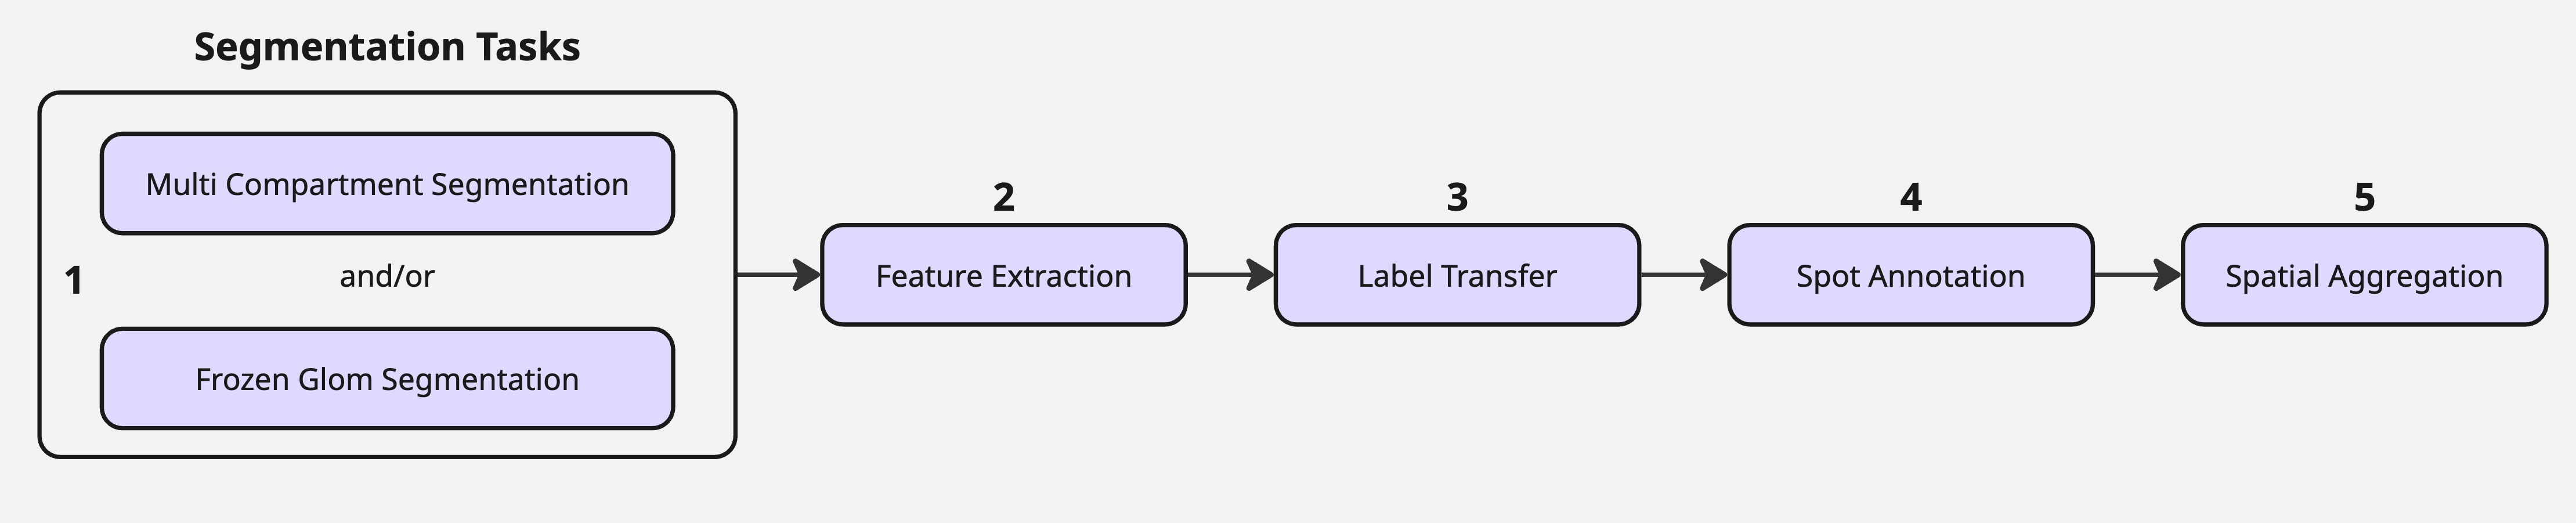

### **Code for Analysis**

#### **Parameters for Each Analysis:**

| Step | Analysis                    | Parameter              | Description                                                                 |
|------|----------------------------|------------------------|-----------------------------------------------------------------------------|
| 1    | Multicompartment Segmentation | input_file             | Path to the WSI image (e.g. .tif)                                           |
|      |                            | modelfile              | Path to the segmentation model file                                         |
| 2    | Frozen Glom Segmentation   | input_image            | Path to the WSI image                                                       |
|      |                            | model_file             | Path to the segmentation model file                                         |
| 3    | Feature Extraction         | input_image            | Path to the WSI image                                                       |
|      |                            | annotations_dir        | Auto-derived (Segmented_FTU/ under dataset root)                            |
| 4    | Label Transfer            | counts_file            | Path to the 10X Visium counts/expression file (e.g. .h5ad)                  |
|      |                            | reference              | Path to the reference file (e.g. .h5Seurat)                                                |
|      |                            | organ                  | Hardcoded as KPMP Atlas Kidney                                              |
| 5    | Spot Annotation           | image_file             | Path to the WSI image (used only to locate dataset root)                    |
|      |                            | cell_reference_file    | Path to the cell reference file                                             |
| 6    | Spatial Aggregation       | base_annotation        | Path to the base annotation file (Spots.json)                                           |
|      |                            | agg_annotations        | One or more annotation paths (space-separated)                              |

#### **Running the Analysis Function**

Use `run_analysis()` to launch any analysis task. Choose where you want to run the analyses:

| Parameter | Description |
|---|---|
| `'notebook'` | Runs the analysis on the HuBMAP Workspace. |
| `'fusion'` | Runs the analysis on the Fusion Platform. Requires `gc` and `user_name`. |

To run in the HuBMAP Workspace: 
`run_analysis('notebook')`
> Note: To download the default Model and Reference files use: `run_analysis('notebook', gc=gc)`

To run on the Fusion Platform:
`run_analysis('fusion', gc=gc, user_name=user_name)`

In [ ]:
from fusion import run_analysis

results = run_analysis('notebook')

#### **Checking the Status of the Job**



| Code to Run | Description |
|---|---|
| `check_job_status()` | Helps the user see the status of all submitted jobs in a live-refreshing view |
| `check_job_status('{job_id}', 'live_logs')` | Helps the user see the logs for the job_id mentioned |

- job_id → The unique identifier of the job you want to monitor

- 'live_logs' → Enables real-time log streaming for that job

> All the logs can be found under: *fusion_demo_notebooks/datasets/{_hubmap_id_of_image}/logs*

In [ ]:
from fusion import check_job_status

check_job_status()

# **Visualisation**

Use `visualize_wsi()` to visualise data in the FUSION interface.

| Parameter | Type | Description | Required |
|-----------|------|-------------|----------|
| `gc` | object | Girder client instance (only needed when using Fusion Platform) | Yes |
| `item_id` | str | Item ID of the file to visualise (only needed when using Fusion Platform)| `item_id` or `hubmap_id` |
| `hubmap_id` | str | HuBMAP dataset ID (use for HuBMAP data) | `item_id` or `hubmap_id` |
| `user` | str | Username for authentication | Yes (except when using `item_id`) |
| `dir_path` | str | Local directory path containing WSI or Visium-related output. | Required if not using `item_id` or `hubmap_id`
To open up visual tool: `visualize_wsi(gc, user=user_name)` 
> This tool can also be used to navigate the files in the Fusion Platform

To visualise HuBMAP data: `visualize_wsi(gc, hubmap_id='hubmap_id', user='user_name')`

To visualise a specific item from Fusion: `visualize_wsi(gc, item_id='your_item_id', user='user_name')`

To visualise data from local directory: `visualize_wsi(gc, dir_path='/path/to/your/dataset_directory', user='user_name')`

In [ ]:
from fusion.utilities.visualize import visualize_wsi

result = visualize_wsi(gc, user='', dir_path='')
result

# **Other Possibilities**

## **Metadata Plotting**

In [ ]:
import pandas as pd

import numpy as np

import scanpy as sc

import anndata as ad

import json

import os

from pydeseq2.dds import DeseqDataSet

from pydeseq2.ds import DeseqStats

import matplotlib.pyplot as plt

import seaborn as sns
 
# =============================================================================

# SECTION 1: Parse the Barcode-to-Case CSV

# =============================================================================

csv_path = "/hive/user-workspaces/injarapu/1843/Metadata_plot/barcode-and-case.csv"

# Load CSV and drop unassigned cases [1, 2]

barcode_case = pd.read_csv(csv_path).dropna(subset=['Case'])

barcode_case = barcode_case[barcode_case['Case'] != ""]
 
# Recover true barcodes by stripping Loupe suffixes (-1/-2) [2, 3]

def get_true_barcode(bc):

    return bc.rsplit('-', 1)[0] + "-1"
 
barcode_case['true_barcode'] = barcode_case['Barcode'].apply(get_true_barcode)

barcode_case['condition'] = np.where(barcode_case['Case'].str.contains('control'), 'control', 'active_amr')
 
# Split for lookup [4]

amr_lookup = barcode_case[barcode_case['condition'] == 'active_amr'].set_index('true_barcode')

ctrl_lookup = barcode_case[barcode_case['condition'] == 'control'].set_index('true_barcode')
 
# =============================================================================

# SECTION 2: Helper Function -- Parse FUSION JSON

# =============================================================================

def parse_glom_json(json_path, condition_label):

    with open(json_path, 'r') as f:

        data = json.load(f)

    glom_records = []

    # Extract structure instances and their associated barcodes [4, 5]

    for i, element in enumerate(data['annotation']['elements']):

        struct_id = f"Glomerulus_{i+1}_{condition_label}"

        # Adjust the key 'points' or 'barcodes' based on your JSON structure [5]

        barcodes = element['user']['barcode_Aggregated'].get('Count', []) 

        for bc in barcodes:

            glom_records.append({'barcode': bc, 'structure_id': struct_id})

    return pd.DataFrame(glom_records)
 
# =============================================================================

# SECTION 3 & 4: Load Data and Annotate [6, 7]

# =============================================================================

# Loading pre-converted h5ad files

adata_amr = sc.read_h5ad("/hive/user-workspaces/injarapu/1843/Metadata_plot/chen-LLU-active-amr-visium_integrated.h5ad")

adata_ctrl = sc.read_h5ad("/hive/user-workspaces/injarapu/1843/Metadata_plot/chen-LLU-control-visium_integrated.h5ad")
 
def annotate_adata(adata, lookup_df, condition):

    # Map case_id and condition [8]

    adata.obs['case_id'] = adata.obs_names.map(lookup_df['Case'])

    adata.obs['condition'] = condition

    return adata
 
adata_amr = annotate_adata(adata_amr, amr_lookup, "active_amr")

adata_ctrl = annotate_adata(adata_ctrl, ctrl_lookup, "control")
 
# Load Glomerular Maps [9]

amr_glom_map = parse_glom_json("/hive/user-workspaces/injarapu/1843/Metadata_plot/agg_non_globally_sclerotic_glomeruliactive_AMR.json", "amr")

ctrl_glom_map = parse_glom_json("/hive/user-workspaces/injarapu/1843/Metadata_plot/agg_non_globally_sclerotic_glomeruli_control.json", "ctrl")
 
# =============================================================================

# SECTION 5 & 6: Subset and Pseudo-Bulk Aggregation

# =============================================================================

def get_glom_pseudobulk(adata, glom_map):

    # Subset to glomerular spots with valid case IDs [10, 11]

    adata.obs['structure_id'] = adata.obs_names.map(glom_map.set_index('barcode')['structure_id'])

    subset = adata[adata.obs['structure_id'].notna() & adata.obs['case_id'].notna()].copy()

    print(subset)

    # Aggregate counts (sum) by structure_id [12, 13]

    # In Scanpy, we can use the following to get a new AnnData of summed counts

    pb_adata = ad.AnnData(

        X = pd.DataFrame(subset.X.toarray(), index=subset.obs_names, columns=subset.var_names)

            .groupby(subset.obs['structure_id']).sum(),

        var = subset.var

    )

    # Carry over metadata

    pb_metadata = subset.obs[['structure_id', 'condition', 'case_id']].drop_duplicates().set_index('structure_id')

    pb_adata.obs = pb_metadata.loc[pb_adata.obs_names]

    return pb_adata
 
pb_amr = get_glom_pseudobulk(adata_amr, amr_glom_map)

pb_ctrl = get_glom_pseudobulk(adata_ctrl, ctrl_glom_map)
 
# Combine datasets [14]

pb_combined = ad.concat([pb_amr, pb_ctrl])
 
# =============================================================================

# SECTION 8: PyDESeq2 Analysis [15-17]

# =============================================================================

# Filter low-count genes (sum across all samples >= 10)

sc.pp.filter_genes(pb_combined, min_counts=10)
 
# Initialize DESeq2 object

# PyDESeq2 requires raw counts in integer format

dds = DeseqDataSet(

    counts=pd.DataFrame(pb_combined.X.astype(int), index=pb_combined.obs_names, columns=pb_combined.var_names),

    metadata=pb_combined.obs,

    design_factors="condition",

    refit_cooks=True

)
 
dds.deseq2()
 
# Extract results (Active AMR vs Control)

stat_res = DeseqStats(dds, contrast=["condition", "active_amr", "control"])

stat_res.summary()

de_df = stat_res.results_df

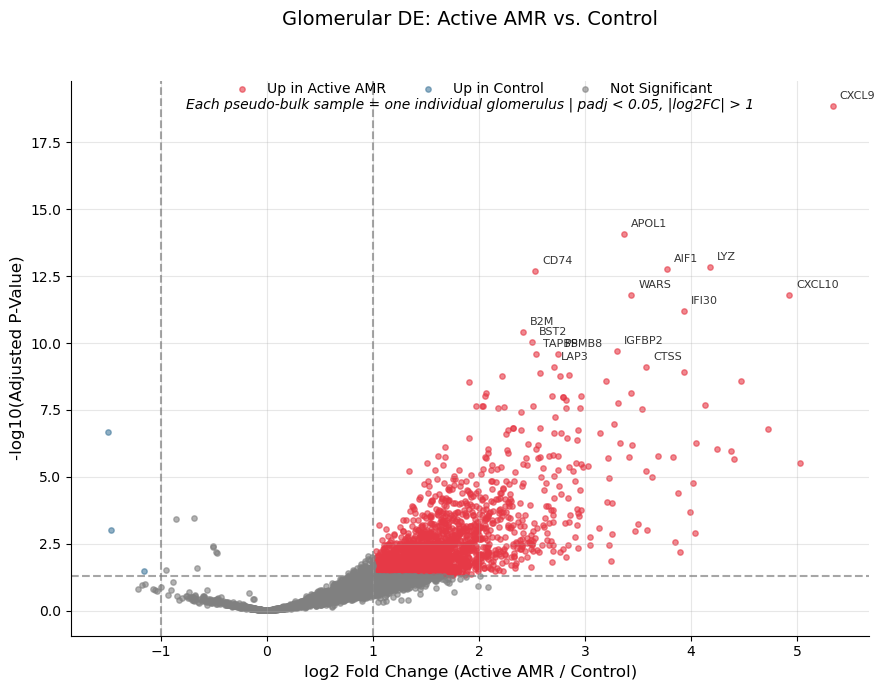

In [6]:
de_df = pd.read_csv("/hive/user-workspaces/injarapu/1843/Metadata_plot/DE_ActiveAMR_vs_Control_Glomeruli.csv")

import matplotlib.pyplot as plt
import numpy as np
 
# Create significance column
def assign_significance(row):
    if row['padj'] < 0.05 and row['log2FoldChange'] > 1:
        return "Up in Active AMR"
    elif row['padj'] < 0.05 and row['log2FoldChange'] < -1:
        return "Up in Control"
    else:
        return "Not Significant"
 
de_df['significance'] = de_df.apply(assign_significance, axis=1)
 
# Get top 15 genes for labeling
top_label_genes = de_df[de_df['padj'] < 0.05].head(15)
 
# Create the volcano plot
fig, ax = plt.subplots(figsize=(9, 7))
 
# Define colors
colors = {
    "Up in Active AMR": "#E63946",
    "Up in Control": "#457B9D", 
    "Not Significant": "grey"
}
 
# Plot points by significance group
for sig_type, color in colors.items():
    subset = de_df[de_df['significance'] == sig_type]
    ax.scatter(subset['log2FoldChange'], -np.log10(subset['padj']), 
              c=color, alpha=0.6, s=15, label=sig_type)
 
# Add threshold lines
ax.axhline(y=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7)
ax.axvline(x=-1, color='grey', linestyle='--', alpha=0.7)
ax.axvline(x=1, color='grey', linestyle='--', alpha=0.7)
 
# Add gene labels for top genes (using actual gene names from index)
for idx, row in top_label_genes.iterrows():
    ax.annotate(row['gene'], (row['log2FoldChange'], -np.log10(row['padj'])), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, alpha=0.8)
 
# Add legend at the top
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), 
                  ncol=3, frameon=False, fontsize=10)
 
# Customize plot
ax.set_xlabel('log2 Fold Change (Active AMR / Control)', fontsize=12)
ax.set_ylabel('-log10(Adjusted P-Value)', fontsize=12)
ax.set_title('Glomerular DE: Active AMR vs. Control', fontsize=14, pad=40)
ax.text(0.5, 0.95, 'Each pseudo-bulk sample = one individual glomerulus | padj < 0.05, |log2FC| > 1', 
        transform=ax.transAxes, ha='center', fontsize=10, style='italic')
 
# Clean up plot appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("volcano_ActiveAMR_vs_Control_Glomeruli.pdf", dpi=300, bbox_inches='tight')
plt.show()

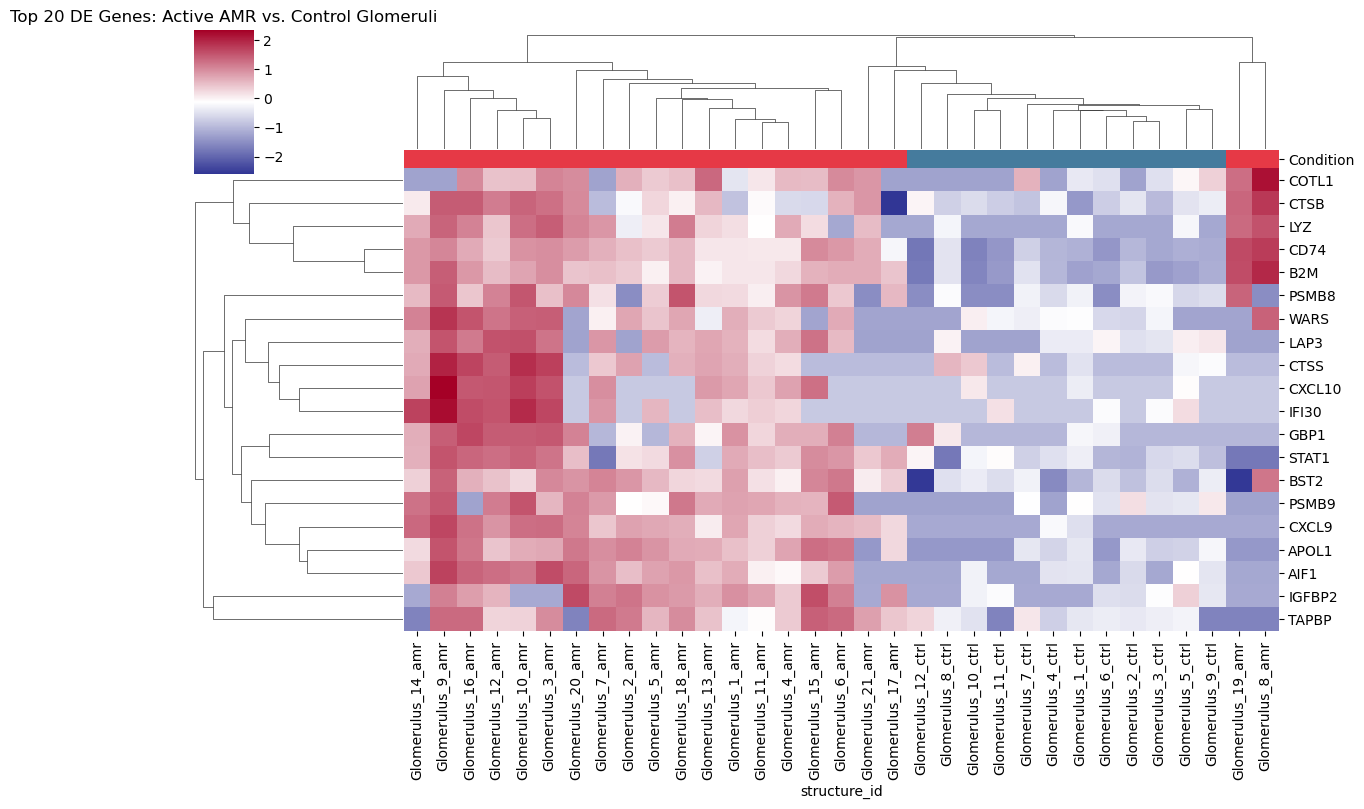

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
 
# =============================================================================
# SECTION 10: Heatmap of Top 20 DE Genes
# =============================================================================
 
# Top 20 genes
top20_genes = (
    de_df.loc[~de_df["padj"].isna()]
         .head(20)["gene"]
         .tolist()
)
sample_metadata = pd.read_csv("/hive/user-workspaces/injarapu/1815/LLU_plotting_input/output/sample_metadata_renamed.csv", index_col=0)
# Variance-stabilizing transformation (approximation)
vst_data = dds.copy()
sc.pp.normalize_total(vst_data, target_sum=1e4)
sc.pp.log1p(vst_data)
 
# Extract matrix
heatmap_mat = vst_data[:, top20_genes].X.T
 
# Convert to DataFrame for easier handling
heatmap_mat = pd.DataFrame(
    heatmap_mat,
    index=top20_genes,
    columns=vst_data.obs_names
)
 
# Scale each gene (row-wise z-score)
heatmap_mat_scaled = heatmap_mat.sub(heatmap_mat.mean(axis=1), axis=0) \
                               .div(heatmap_mat.std(axis=1), axis=0)
 
# Column annotationvv
col_annotation = pd.DataFrame({
    "Condition": sample_metadata.loc[heatmap_mat_scaled.columns, "condition"],
    "Donor": sample_metadata.loc[heatmap_mat_scaled.columns, "case_id"]
})
 
# Annotation colors
annotation_colors = {
    "active_amr": "#E63946",
    "control": "#457B9D"
}
 
# Map colors for seaborn
col_colors = col_annotation["Condition"].map(annotation_colors)
 
# Custom heatmap colormap
cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#313695", "white", "#A50026"]
)
 
# Plot heatmap
heatmap_obj = sns.clustermap(
    heatmap_mat_scaled,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    cmap=cmap,
    xticklabels=True,
    yticklabels=True,
    figsize=(12, 8)
)
 
plt.title("Top 20 DE Genes: Active AMR vs. Control Glomeruli")
 
# Save to PDF
plt.savefig("heatmap_top20_ActiveAMR_vs_Control_Glomeruli.pdf")
 
plt.show()

In [2]:
from fusion.utilities.visualize import visualize_wsi

result = visualize_wsi(gc, user=user_name)
result

![glom_8](Images/glom_8.png)

### Other plot ideas:
BayesSpace for subspot resolution, Pathway Analysis etc.

### Summary:
- All data added to the workspace is persisted, so it remains available when you return.
- The notebook preserves its current state, including outputs, making it easy to share workflows, while keeping your data private.
- With integrated flowcharts and documentation, it serves as an effective tool for teaching.
- With a code-based environment and available FUSION++ features, it provides a flexible platform to bring your own data, perform custom analyses, create visualizations, and build workflows tailored to your needs.